In [1]:
SEED = 42
import numpy as np
import torch
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
from pathlib import Path
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
import sys
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR   = Path("../data/processed/FD001")
MODELS_DIR = Path("../data/processed/FD001/checkpoints")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X      = np.load(DATA_DIR / "X_train.npy")
y      = np.load(DATA_DIR / "y_train.npy")
labels = np.load(DATA_DIR / "labels_train.npy")

INPUT_DIM = X.shape[2]

SEQ_LEN     = X.shape[1]
HIDDEN_DIM  = 48
LATENT_DIM  = 48
NUM_LAYERS  = 3
NUM_CLASSES = 4
EMBED_DIM   = 8
BATCH_SIZE  = 64

cfg = {
    "seq_len"    : SEQ_LEN,
    "input_dim"  : INPUT_DIM,
    "hidden_dim" : HIDDEN_DIM,
    "latent_dim" : LATENT_DIM,
    "num_layers" : NUM_LAYERS,
    "num_classes": NUM_CLASSES,
    "embed_dim"  : EMBED_DIM,
}
with open("../configs/model_config.json", "w") as f:
    json.dump(cfg, f, indent=2)

print(f"X      : {X.shape}")
print(f"labels : {labels.shape}")
print(f"Device : {DEVICE}")
print(f"INPUT_DIM auto-detected: {INPUT_DIM}")
print(f"Config : {cfg}")

X      : (17731, 30, 17)
labels : (17731,)
Device : cpu
INPUT_DIM auto-detected: 17
Config : {'seq_len': 30, 'input_dim': 17, 'hidden_dim': 48, 'latent_dim': 48, 'num_layers': 3, 'num_classes': 4, 'embed_dim': 8}


In [2]:
class CMAPSSDataset(Dataset):
    def __init__(self, X, labels):
        self.X      = torch.tensor(X,      dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.labels[idx]


BATCH_SIZE = 64

dataset    = CMAPSSDataset(X, labels)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Dataset size  : {len(dataset)}")
print(f"Batches/epoch : {len(dataloader)}")

Dataset size  : 17731
Batches/epoch : 277


In [3]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.gru  = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
    def forward(self, x):
        h, _ = self.gru(x)
        return self.proj(h)

class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.gru  = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.proj = nn.Linear(hidden_dim, output_dim)  # no activation — clamp instead
    def forward(self, h):
        out, _ = self.gru(h)
        return torch.clamp(self.proj(out), 0.0, 1.0)   # hard clamp to [0,1]

class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.gru  = nn.GRU(hidden_dim, hidden_dim, max(1, num_layers-1), batch_first=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
    def forward(self, h):
        out, _ = self.gru(h)
        return self.proj(out)

class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_layers, num_classes, embed_dim):
        super().__init__()
        self.class_embed = nn.Embedding(num_classes, embed_dim)
        self.gru  = nn.GRU(latent_dim + embed_dim, hidden_dim, num_layers, batch_first=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.noise_scale = 0.3   # increased from 0.1

    def forward(self, z, c):
        emb = self.class_embed(c).unsqueeze(1).repeat(1, z.size(1), 1)
        z_noisy = z + self.noise_scale * torch.randn_like(z)
        inp  = torch.cat([z_noisy, emb], dim=-1)
        h, _ = self.gru(inp)
        return self.proj(h)

class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers, num_classes, embed_dim):
        super().__init__()
        self.class_embed = nn.Embedding(num_classes, embed_dim)
        self.gru  = nn.GRU(hidden_dim + embed_dim, hidden_dim, num_layers, batch_first=True)
        self.proj = nn.Linear(hidden_dim, 1)
    def forward(self, h, c):
        emb = self.class_embed(c).unsqueeze(1).repeat(1, h.size(1), 1)
        out, _ = self.gru(torch.cat([h, emb], dim=-1))
        return self.proj(out)


embedder      = Embedder(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS).to(DEVICE)
recovery      = Recovery(HIDDEN_DIM, INPUT_DIM, NUM_LAYERS).to(DEVICE)
supervisor    = Supervisor(HIDDEN_DIM, NUM_LAYERS).to(DEVICE)
generator     = Generator(LATENT_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, EMBED_DIM).to(DEVICE)
discriminator = Discriminator(HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, EMBED_DIM).to(DEVICE)

print("All models initialised.")

All models initialised.


In [4]:
LR = 1e-3

opt_embedder      = torch.optim.Adam(list(embedder.parameters()) + list(recovery.parameters()),   lr=LR)
opt_supervisor    = torch.optim.Adam(list(embedder.parameters()) + list(supervisor.parameters()), lr=LR)
opt_generator     = torch.optim.Adam(list(generator.parameters()) + list(supervisor.parameters()), lr=LR)
opt_discriminator = torch.optim.Adam(discriminator.parameters(), lr=LR)

bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def loss_reconstruction(x, x_recon):
    return 5.0 * torch.sqrt(mse(x, x_recon))   # was 10.0

def loss_supervisor_fn(h, h_sup):
    return 5.0 * torch.sqrt(mse(h[:, 1:, :], h_sup[:, :-1, :]))   # was 10.0

def loss_generator_fn(d_fake, h, h_hat_sup, x, x_hat, gamma=2.0):   # gamma up from 1.0
    L_GAN  = bce(d_fake, torch.ones_like(d_fake))
    L_sup  = 5.0 * torch.sqrt(mse(h[:, 1:, :], h_hat_sup[:, :-1, :]))
    L_mean = torch.mean(torch.abs(x.mean(0) - x_hat.mean(0)))
    L_var  = torch.mean(torch.abs(
        torch.sqrt(x.var(0) + 1e-6) - torch.sqrt(x_hat.var(0) + 1e-6)
    ))
    return L_GAN + gamma * (L_mean + L_var) + L_sup

def loss_discriminator_fn(d_real, d_fake):
    return (bce(d_real, torch.ones_like(d_real)) +
            bce(d_fake, torch.zeros_like(d_fake))) / 2.0

print("Optimizers and losses ready.")

Optimizers and losses ready.


In [5]:
EPOCHS_AE = 100
history_ae = []

print("Phase 1: Autoencoder pretraining...")
for epoch in range(EPOCHS_AE):
    epoch_loss = 0.0
    for x_batch, _ in dataloader:
        x_batch = x_batch.to(DEVICE)

        H = embedder(x_batch)
        X_rec = recovery(H)
        loss  = loss_reconstruction(x_batch, X_rec)

        opt_embedder.zero_grad()
        loss.backward()
        opt_embedder.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(dataloader)
    history_ae.append(avg)
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:>3}/{EPOCHS_AE}  recon_loss={avg:.4f}")

print("Phase 1 complete.")

Phase 1: Autoencoder pretraining...
  Epoch  10/100  recon_loss=0.7177
  Epoch  20/100  recon_loss=0.7022
  Epoch  30/100  recon_loss=0.7020
  Epoch  40/100  recon_loss=0.7019
  Epoch  50/100  recon_loss=0.7020
  Epoch  60/100  recon_loss=0.7020
  Epoch  70/100  recon_loss=0.7018
  Epoch  80/100  recon_loss=0.7018
  Epoch  90/100  recon_loss=0.7018
  Epoch 100/100  recon_loss=0.7018
Phase 1 complete.


In [6]:
EPOCHS_SUP = 100
history_sup = []

print("Phase 2: Supervisor pretraining...")
for epoch in range(EPOCHS_SUP):
    epoch_loss = 0.0
    for x_batch, _ in dataloader:
        x_batch = x_batch.to(DEVICE)

        with torch.no_grad():
            H = embedder(x_batch)
        H_sup = supervisor(H)
        loss  = loss_supervisor_fn(H, H_sup)

        opt_supervisor.zero_grad()
        loss.backward()
        opt_supervisor.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(dataloader)
    history_sup.append(avg)
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:>3}/{EPOCHS_SUP}  sup_loss={avg:.4f}")

print("Phase 2 complete.")

Phase 2: Supervisor pretraining...
  Epoch  10/100  sup_loss=0.2098
  Epoch  20/100  sup_loss=0.2086
  Epoch  30/100  sup_loss=0.2072
  Epoch  40/100  sup_loss=0.2052
  Epoch  50/100  sup_loss=0.2029
  Epoch  60/100  sup_loss=0.2006
  Epoch  70/100  sup_loss=0.1987
  Epoch  80/100  sup_loss=0.1973
  Epoch  90/100  sup_loss=0.1961
  Epoch 100/100  sup_loss=0.1951
Phase 2 complete.


In [7]:
EPOCHS_GAN = 300   
history_g, history_d = [], []

print("Phase 3: Joint GAN training...")
for epoch in range(EPOCHS_GAN):
    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    for x_batch, c_batch in dataloader:
        x_batch = x_batch.to(DEVICE)
        c_batch = c_batch.to(DEVICE)
        z       = torch.randn(BATCH_SIZE, SEQ_LEN, LATENT_DIM).to(DEVICE)

        H       = embedder(x_batch)
        H_hat   = generator(z, c_batch)
        H_hat_s = supervisor(H_hat)
        X_hat   = recovery(H_hat)
        D_fake  = discriminator(H_hat_s, c_batch)

        g_loss = loss_generator_fn(D_fake, H, H_hat_s, x_batch, X_hat)
        opt_generator.zero_grad()
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(),  1.0)
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        opt_generator.step()

        with torch.no_grad():
            H       = embedder(x_batch)
            H_hat   = generator(z, c_batch)
            H_hat_s = supervisor(H_hat)

        D_real = discriminator(H,       c_batch)
        D_fake = discriminator(H_hat_s, c_batch)
        d_loss = loss_discriminator_fn(D_real, D_fake)

        if d_loss.item() > 0.15:
            opt_discriminator.zero_grad()
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            opt_discriminator.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    g_avg = g_loss_epoch / len(dataloader)
    d_avg = d_loss_epoch / len(dataloader)
    history_g.append(g_avg)
    history_d.append(d_avg)

    if (epoch + 1) % 25 == 0:
        print(f"  Epoch {epoch+1:>3}/{EPOCHS_GAN}  G={g_avg:.4f}  D={d_avg:.4f}")

print("Phase 3 complete.")

Phase 3: Joint GAN training...
  Epoch  25/300  G=1.1238  D=0.6928
  Epoch  50/300  G=1.1216  D=0.6920
  Epoch  75/300  G=1.1343  D=0.6878
  Epoch 100/300  G=1.1618  D=0.7035
  Epoch 125/300  G=1.1945  D=0.6672
  Epoch 150/300  G=1.1399  D=0.6934
  Epoch 175/300  G=1.1717  D=0.6917
  Epoch 200/300  G=1.2119  D=0.6529
  Epoch 225/300  G=1.1049  D=0.6867
  Epoch 250/300  G=1.1232  D=0.6978
  Epoch 275/300  G=1.1170  D=0.6908
  Epoch 300/300  G=1.2787  D=0.6777
Phase 3 complete.


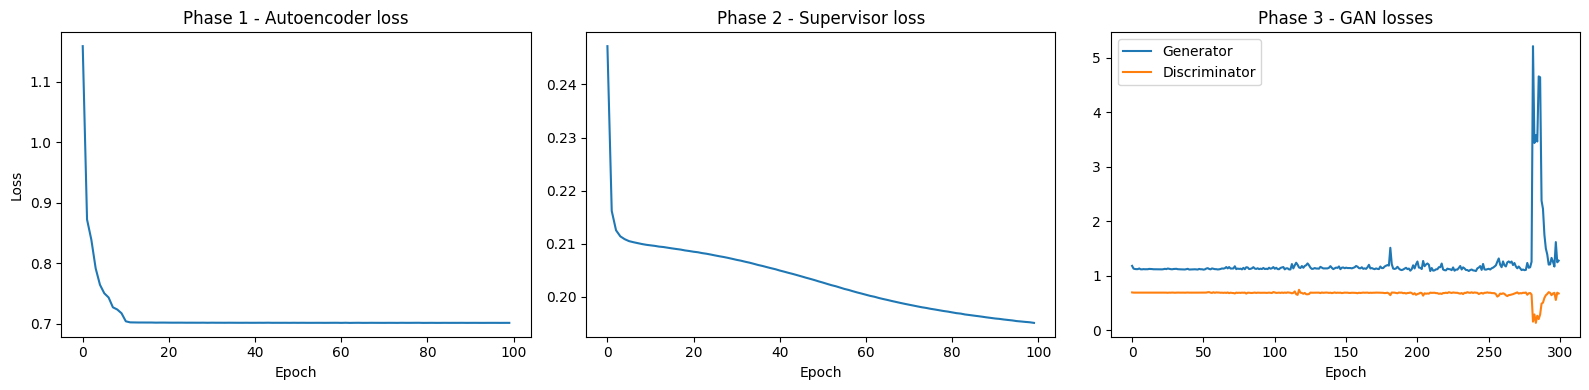

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_ae)
axes[0].set_title("Phase 1 - Autoencoder loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history_sup)
axes[1].set_title("Phase 2 - Supervisor loss")
axes[1].set_xlabel("Epoch")

axes[2].plot(history_g, label="Generator")
axes[2].plot(history_d, label="Discriminator")
axes[2].set_title("Phase 3 - GAN losses")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig("../reports/figures/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
torch.save(embedder.state_dict(),      MODELS_DIR / "embedder.pt")
torch.save(recovery.state_dict(),      MODELS_DIR / "recovery.pt")
torch.save(supervisor.state_dict(),    MODELS_DIR / "supervisor.pt")
torch.save(generator.state_dict(),     MODELS_DIR / "generator.pt")
torch.save(discriminator.state_dict(), MODELS_DIR / "discriminator.pt")

with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(cfg, f, indent=2)

print(f"All checkpoints saved -> {MODELS_DIR.resolve()}")
print("Config snapshot saved alongside checkpoints.")

All checkpoints saved -> C:\Users\Ishaan Nandoskar\Downloads\nasa_gan_turbo_fan_engine\data\processed\FD001\checkpoints
Config snapshot saved alongside checkpoints.


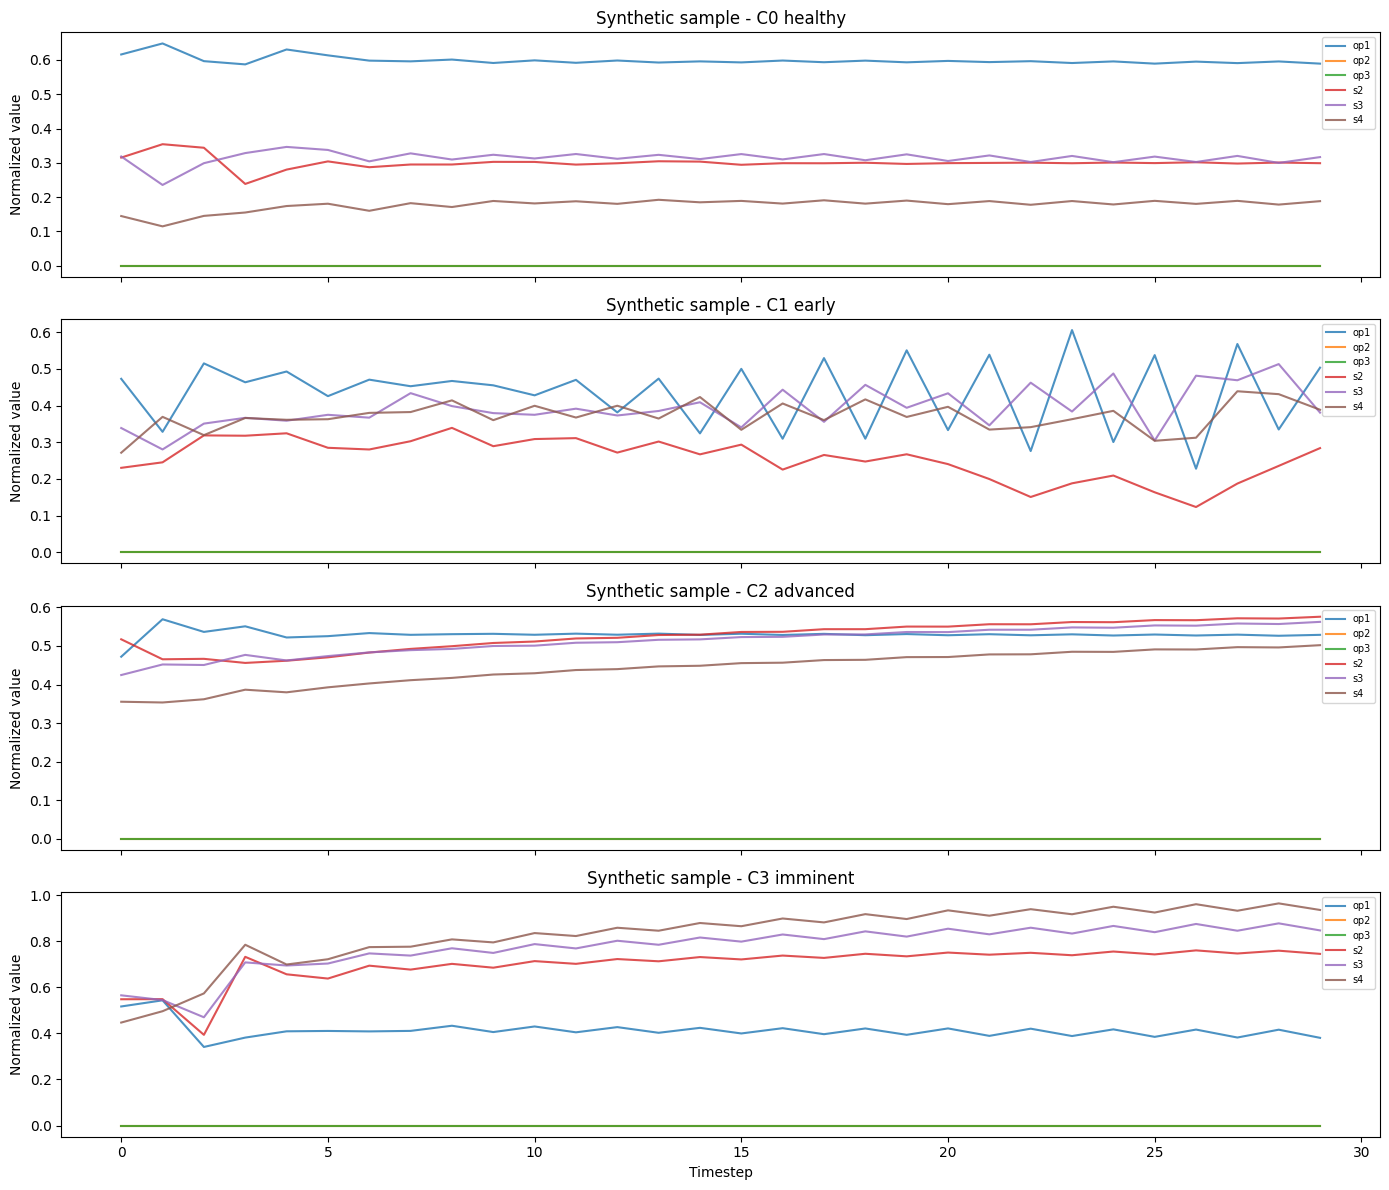

In [12]:
CLASS_NAMES  = ["C0 healthy", "C1 early", "C2 advanced", "C3 imminent"]
FEATURE_COLS = [
    "op1","op2","op3",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]

embedder.eval(); recovery.eval()
supervisor.eval(); generator.eval()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

with torch.no_grad():
    for c in range(4):
        z        = torch.randn(1, SEQ_LEN, LATENT_DIM).to(DEVICE)
        c_tensor = torch.tensor([c]).to(DEVICE)
        H_hat    = generator(z, c_tensor)
        H_hat_s  = supervisor(H_hat)
        X_hat    = recovery(H_hat_s).cpu().numpy()[0]

        ax = axes[c]
        for i, col in enumerate(FEATURE_COLS[:6]):
            ax.plot(X_hat[:, i], label=col, alpha=0.8)
        ax.set_title(f"Synthetic sample - {CLASS_NAMES[c]}")
        ax.set_ylabel("Normalized value")
        ax.legend(loc="upper right", fontsize=7)

axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.savefig("../reports/figures/synthetic_samples_per_class.png", dpi=150, bbox_inches="tight")
plt.show()